<a href="https://colab.research.google.com/github/Shahbaazmohd/Minor_Project/blob/main/Currency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Initial setup cell
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications import (VGG16, ResNet50, EfficientNetB0)  # Common transfer learning models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Check TensorFlow version and GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# 1. Use absolute paths with pathlib (recommended)
project_root = Path("/content/drive/MyDrive/currency")
data_dir = project_root / "dataset"

# 2. Define paths - use your actual folder names
train_dir = data_dir / "training"      # dataset/training
val_dir = data_dir / "validation"      # dataset/validation
test_dir = data_dir / "testing"        # dataset/testing

# 3. Verify paths exist
print("Verifying paths...")
print(f"Project root: {project_root.exists()}")
print(f"Data directory: {data_dir.exists()}")
print(f"Train directory: {train_dir.exists()} ({len(list(train_dir.glob('*')))} subfolders)")
print(f"Validation directory: {val_dir.exists()}")
print(f"Test directory: {test_dir.exists()} ({len(list(test_dir.glob('*')))} subfolders)")

# 4. Check folder contents
def check_folder_structure():
    print("\nFolder structure verification:")
    for split in [train_dir, val_dir, test_dir]:
        print(f"\n{split.name}:")
        if split.exists():
            for class_name in ['real', 'fake']:  # Using your actual class names
                class_path = split / class_name
                print(f"  {class_name}: ", end="")
                if class_path.exists():
                    num_images = len(list(class_path.glob('*.*')))
                    print(f"{num_images} images")
                else:
                    print("MISSING")
        else:
            print("  Directory not found")

check_folder_structure()


Verifying paths...
Project root: True
Data directory: True
Train directory: True (3 subfolders)
Validation directory: True
Test directory: True (3 subfolders)

Folder structure verification:

training:
  real: 1387 images
  fake: 1388 images

validation:
  real: 296 images
  fake: 296 images

testing:
  real: 297 images
  fake: 297 images


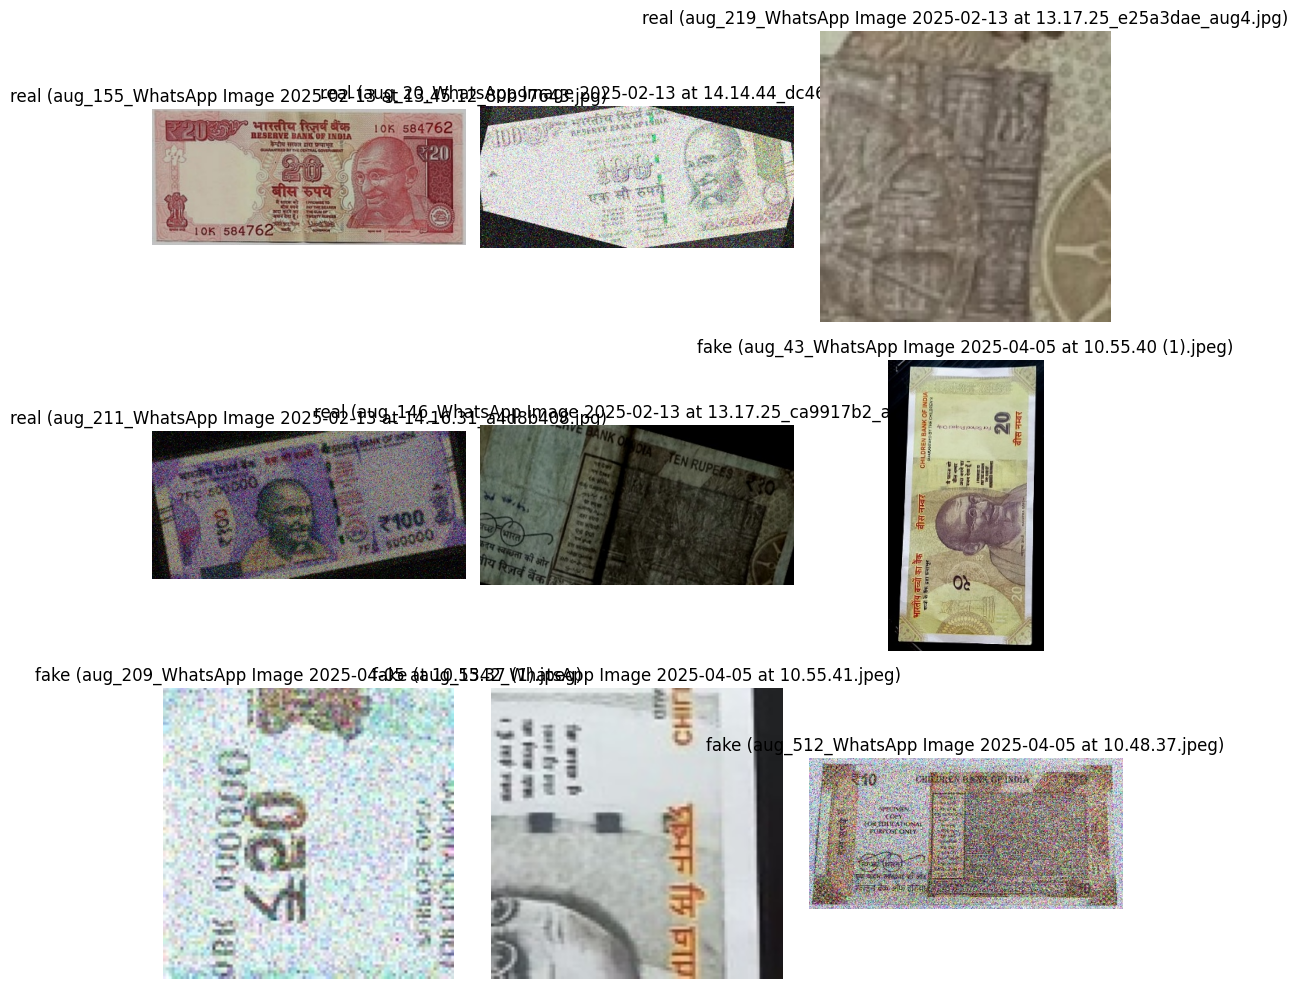

In [ ]:
def plot_sample_images():
    plt.figure(figsize=(10, 10))
    images_shown = 0

    # Loop through both classes
    for class_idx, class_name in enumerate(['real', 'fake']):  # Your actual folder names
        class_path = train_dir / class_name

        if not class_path.exists():
            print(f"Warning: {class_path} not found")
            continue

        # Get first 4-5 images from each class
        image_files = list(class_path.glob('*.*'))[:5]

        for i, img_path in enumerate(image_files):
            if images_shown >= 9:
                break

            plt.subplot(3, 3, images_shown + 1)
            try:
                img = Image.open(img_path)
                plt.imshow(img)
                plt.title(f"{class_name} ({img_path.name})")
                plt.axis("off")
                images_shown += 1
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    if images_shown == 0:
        print("No images found in:", train_dir)
    else:
        plt.tight_layout()
        plt.show()

plot_sample_images()

In [ ]:
print("Current working directory:", os.getcwd())
# If wrong, change it:
os.chdir(r"/content/drive/MyDrive/currency")

Current working directory: /content


In [ ]:
import os
print(f"Readable: {os.access(train_dir, os.R_OK)}")
print(f"Executable: {os.access(train_dir, os.X_OK)}")

Readable: True
Executable: True


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Using your actual folder names
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    classes=['real', 'fake']  # Your actual class folders
)

print("\nFound classes:", train_generator.class_indices)

Found 2774 images belonging to 2 classes.

Found classes: {'real': 0, 'fake': 1}


In [ ]:
# Image dimensions
img_height, img_width = 224, 224  # Standard size for many transfer learning models
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test data should not be augmented
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # or 'categorical' if you have more classes
    color_mode='rgb'  # Explicitly set RGB mode
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb'  # Explicitly set RGB mode
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb'  # Explicitly set RGB mode
)

Found 2774 images belonging to 2 classes.
Found 592 images belonging to 2 classes.
Found 594 images belonging to 2 classes.


In [ ]:
# Verify Image Channels:
    #check to confirm image shapes:

for images, _ in train_generator:
    print("Image shape:", images.shape[1:])  # Should be (224, 224, 3)
    break

Image shape: (224, 224, 3)


In [ ]:
# Train with Xception model (better for currency detection)
from tensorflow.keras.applications import Xception

# Build new model
base_model = Xception(
    include_top=False,
    weights='imagenet',
    input_shape=(img_height, img_width, 3),
    pooling='avg'
)

inputs = keras.Input(shape=(img_height, img_width, 3))
x = base_model(inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

# Compile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386,281 (81.58 MB)

 Trainable params: 21,331,753 (81.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define enhanced callbacks
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)
]

# Verify model input shape
print("Model input shape:", model.input_shape)  # Should be (None, 224, 224, 3)

Model input shape: (None, 224, 224, 3)


In [ ]:
# Start training
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 769s 8s/step - accuracy: 0.7530 - loss: 0.4649 - val_accuracy: 0.8547 - val_loss: 0.3299 - learning_rate: 1.0000e-04
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 62s 714ms/step - accuracy: 0.9347 - loss: 0.1614 - val_accuracy: 0.9831 - val_loss: 0.0428 - learning_rate: 1.0000e-04
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 66s 747ms/step - accuracy: 0.9744 - loss: 0.0748 - val_accuracy: 0.9645 - val_loss: 0.0953 - learning_rate: 1.0000e-04
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 77s 691ms/step - accuracy: 0.9699 - loss: 0.0887 - val_accuracy: 0.9882 - val_loss: 0.0306 - learning_rate: 1.0000e-04
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 80s 675ms/step - accuracy: 0.9625 - loss: 0.0848 - val_accuracy: 0.9865 - val_loss: 0.0349 - learning_rate: 1.0000e-04
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 83s 688ms/step - accuracy: 0.9834 - loss: 0.0405 - val_accuracy: 0.9865 - val_loss: 0.0329 - learning_rate: 1.0000e-04
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 62s 707ms/step - accur

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Get class names and verify consistency across generators
train_classes = list(train_generator.class_indices.keys())
val_classes = list(val_generator.class_indices.keys())
test_classes = list(test_generator.class_indices.keys())

if train_classes != val_classes or train_classes != test_classes:
    print(f"WARNING: Class mismatch! Train: {train_classes}, Val: {val_classes}, Test: {test_classes}")
    # Use train classes as reference
    class_names = train_classes
else:
    class_names = train_classes

print(f"Consistent class mapping: {class_names}")

Consistent class mapping: ['fake', 'real']


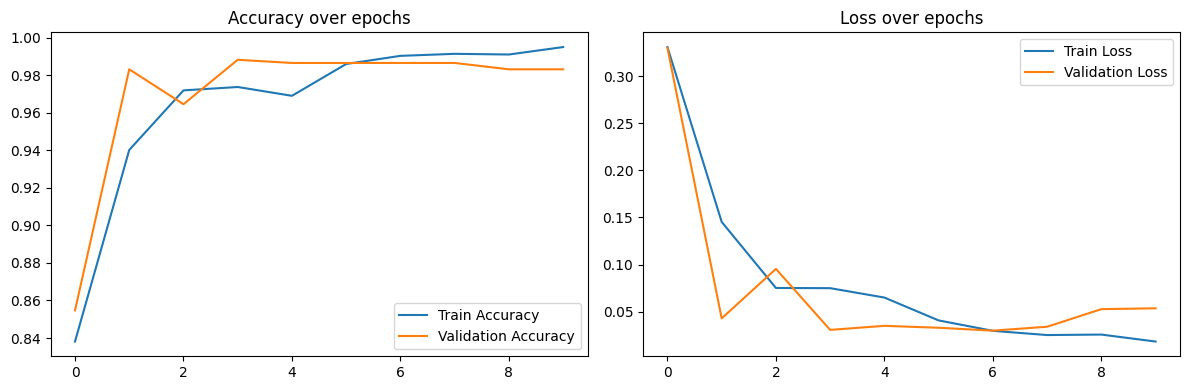

In [ ]:
# 1. Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Key mapping for different TF versions
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'

    plt.subplot(1, 2, 1)
    plt.plot(history.history[acc_key], label='Train Accuracy')
    plt.plot(history.history[val_acc_key], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
# 2. Manual evaluation function to bypass generator issues
def manual_evaluate(model, generator):
    generator.reset()
    y_true = []
    y_pred = []

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        y_true.extend(y_batch)
        batch_pred = model.predict(x_batch, verbose=0)
        y_pred.extend(batch_pred.flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    predicted_classes = (y_pred > 0.5).astype("int32")

    return y_true, predicted_classes, y_pred

In [ ]:
# 3. Perform robust evaluation
true_classes, predicted_classes, prediction_scores = manual_evaluate(model, test_generator)

In [ ]:
# 4. Calculate accuracy manually
accuracy = np.mean(true_classes == predicted_classes)
print(f"\nMANUAL TEST ACCURACY: {accuracy:.2%}")
print(f"Class distribution: {np.unique(true_classes, return_counts=True)}")

In [ ]:
# 5. Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 16})
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
# 6. Enhanced classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(true_classes, predicted_classes,
                            target_names=class_names, digits=4))

In [2]:
import tensorflow as tf
from tensorflow import keras

# Load the saved model
model = keras.models.load_model("/content/drive/MyDrive/currency/currency_detection_production.keras")

# Verify the model is loaded correctly
print("Model loaded successfully!")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")
model.summary()

Model loaded successfully!
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,049,789 (244.33 MB)

 Trainable params: 21,331,753 (81.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 42,663,508 (162.75 MB)

✅ Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,049,789 (244.33 MB)

 Trainable params: 21,331,753 (81.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 42,663,508 (162.75 MB)


Testing with sample images:


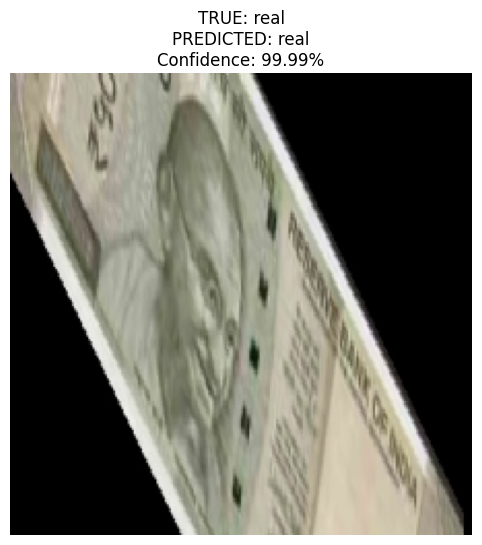

Prediction: real
Confidence: 99.99%
Raw score: 0.9999


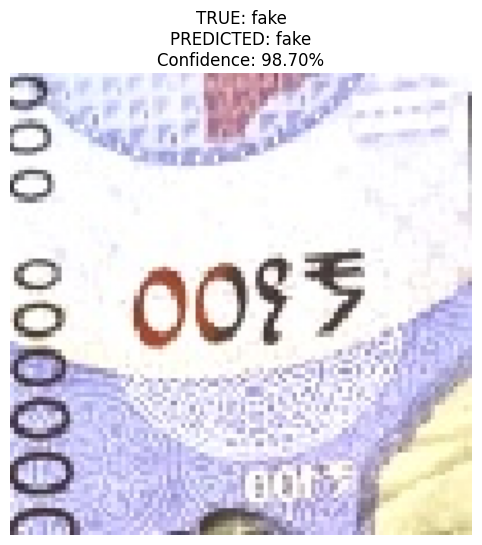

Prediction: fake
Confidence: 98.70%
Raw score: 0.0130


('fake', np.float32(0.9869701))

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Load the saved model
model_path = "/content/drive/MyDrive/currency/currency_detection_production.keras"
model = keras.models.load_model(model_path)

print("✅ Model loaded successfully!")
model.summary()

# Define class names (should match your training setup)
class_names = ['fake', 'real']  # Based on your training data

# Function to test a single image
def test_single_image(model, image_path, true_label=None):
    # Load and preprocess image
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_batch, verbose=0)[0][0]
    predicted_class = class_names[int(prediction > 0.5)]
    confidence = prediction if predicted_class == 'real' else 1 - prediction

    # Display results
    plt.figure(figsize=(8, 6))
    plt.imshow(img_array)
    if true_label:
        plt.title(f"TRUE: {true_label}\nPREDICTED: {predicted_class}\nConfidence: {confidence:.2%}")
    else:
        plt.title(f"PREDICTED: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.axis('off')
    plt.show()

    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Raw score: {prediction:.4f}")

    return predicted_class, confidence

# Test with sample images
print("\nTesting with sample images:")
test_single_image(model, "/content/drive/MyDrive/currency/dataset/testing/real/Screenshot 2025-02-11 143947_aug2.jpg", "real")
test_single_image(model, "/content/drive/MyDrive/currency/dataset/testing/fake/aug_1389_WhatsApp Image 2025-04-05 at 10.59.15.jpeg", "fake")

In [4]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# # Define data generators (same as during training)
# test_dir = "/content/drive/MyDrive/currency/dataset/testing"
# test_datagen = ImageDataGenerator(rescale=1./255)

# test_generator = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=(224, 224),
#     batch_size=32,
#     class_mode='binary',
#     shuffle=False
# )

# # Evaluate on test set
# test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
# print(f"\nTest Accuracy: {test_accuracy:.2%}")
# print(f"Test Loss: {test_loss:.4f}")

Found 594 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 238s 12s/step - accuracy: 0.9937 - loss: 0.0128

Test Accuracy: 98.99%
Test Loss: 0.0232


Simple Saliency Map (Always Works):
Prediction: real, Confidence: 99.99%


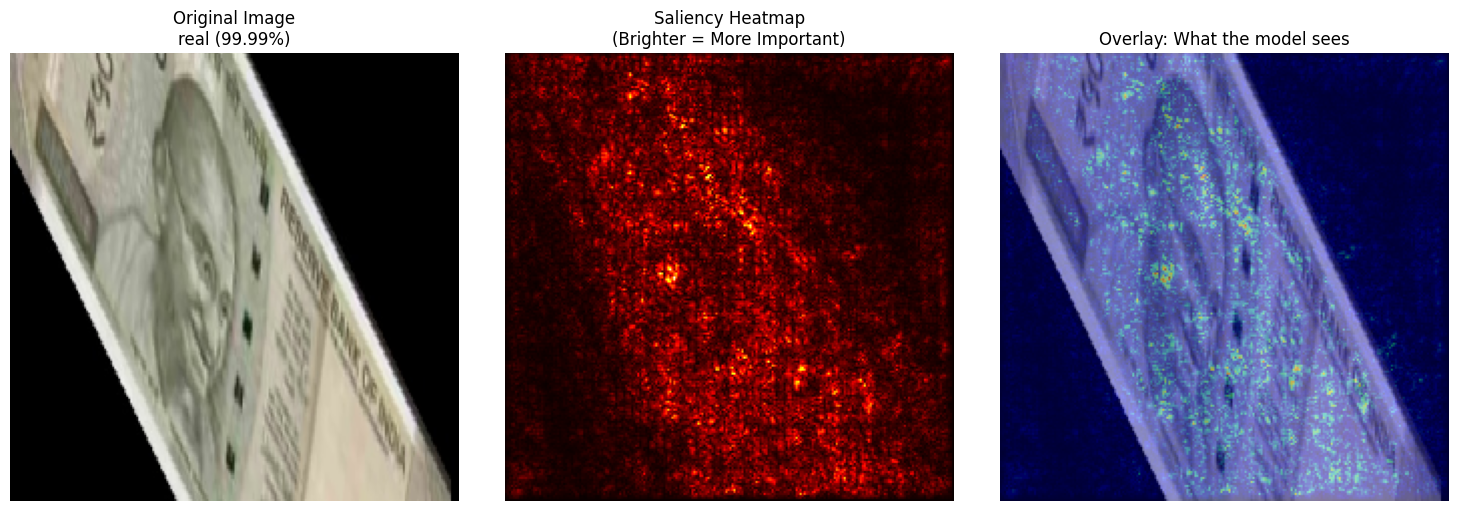


🎯 Saliency Map Interpretation:
• Bright areas: Where the model focuses to make decisions
• For real currency: Should highlight security features
• For fake currency: Might show inconsistent patterns

Testing with Fake Currency:
Prediction: fake, Confidence: 98.70%


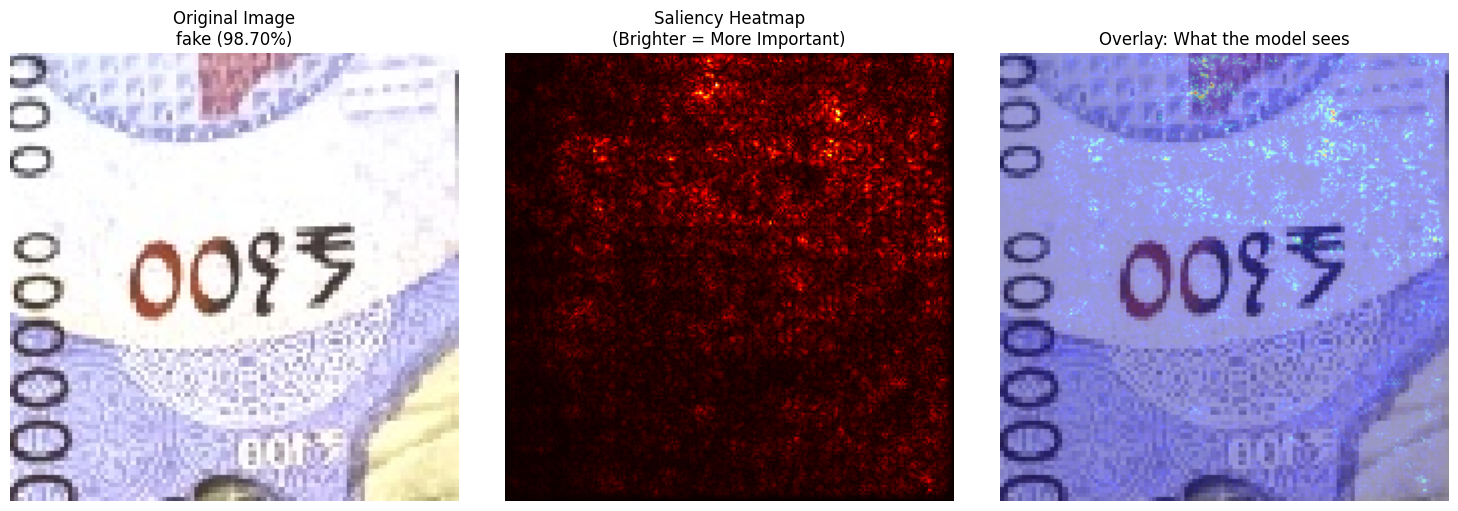


🎯 Saliency Map Interpretation:
• Bright areas: Where the model focuses to make decisions
• For real currency: Should highlight security features
• For fake currency: Might show inconsistent patterns


('fake', np.float32(0.9869701))

In [12]:
def simple_saliency_map(img_path, model):
    """Simple saliency map that always works"""

    # Load image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Convert to tensor
    img_tensor = tf.convert_to_tensor(img_batch)

    # Get prediction
    preds = model.predict(img_batch, verbose=0)
    predicted_class = "real" if preds[0][0] > 0.5 else "fake"
    confidence = preds[0][0] if predicted_class == "real" else 1 - preds[0][0]

    print(f"Prediction: {predicted_class}, Confidence: {confidence:.2%}")

    # Compute gradients
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        prediction = model(img_tensor)[0][0]

    # Get gradients of prediction with respect to input image
    gradients = tape.gradient(prediction, img_tensor)[0]

    # Process gradients to create saliency map
    saliency = tf.reduce_max(tf.abs(gradients), axis=-1)
    saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency))

    # Create visualization
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f'Original Image\n{predicted_class} ({confidence:.2%})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(saliency, cmap='hot')
    plt.title('Saliency Heatmap\n(Brighter = More Important)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(saliency, cmap='jet', alpha=0.4)
    plt.title('Overlay: What the model sees')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("\n🎯 Saliency Map Interpretation:")
    print("• Bright areas: Where the model focuses to make decisions")
    print("• For real currency: Should highlight security features")
    print("• For fake currency: Might show inconsistent patterns")

    return predicted_class, confidence

print("Simple Saliency Map (Always Works):")
test_image_path = "/content/drive/MyDrive/currency/dataset/testing/real/Screenshot 2025-02-11 143947_aug2.jpg"
simple_saliency_map(test_image_path, model)

print("\nTesting with Fake Currency:")
fake_test_path = "/content/drive/MyDrive/currency/dataset/testing/fake/aug_1389_WhatsApp Image 2025-04-05 at 10.59.15.jpeg"
simple_saliency_map(fake_test_path, model)